In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import missingno as msno

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")


Matplotlib is building the font cache; this may take a moment.


In [2]:
print("Environment is working!")

Environment is working!


In [3]:
df = pd.read_csv("../data/raw/credit_risk_dataset.csv")

In [4]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [5]:
df.shape

(32581, 12)

In [6]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='str')

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [11]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 32581
Columns: 12


In [12]:
df.columns.tolist()

['person_age',
 'person_income',
 'person_home_ownership',
 'person_emp_length',
 'loan_intent',
 'loan_grade',
 'loan_amnt',
 'loan_int_rate',
 'loan_status',
 'loan_percent_income',
 'cb_person_default_on_file',
 'cb_person_cred_hist_length']

In [13]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
numerical_columns

['person_age',
 'person_income',
 'person_emp_length',
 'loan_amnt',
 'loan_int_rate',
 'loan_status',
 'loan_percent_income',
 'cb_person_cred_hist_length']

In [14]:
categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()
categorical_columns

/var/folders/h7/xtvfsy8s20z6mwwy81g2ln700000gn/T/ipykernel_60688/799655518.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()


['person_home_ownership',
 'loan_intent',
 'loan_grade',
 'cb_person_default_on_file']

In [15]:
df.isnull().sum()


person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [16]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)


loan_int_rate                 9.563856
person_emp_length             2.747000
person_age                    0.000000
person_income                 0.000000
person_home_ownership         0.000000
loan_intent                   0.000000
loan_grade                    0.000000
loan_amnt                     0.000000
loan_status                   0.000000
loan_percent_income           0.000000
cb_person_default_on_file     0.000000
cb_person_cred_hist_length    0.000000
dtype: float64

In [17]:
df.duplicated().sum()


np.int64(165)

In [8]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [9]:
df.describe(include="object")

/var/folders/h7/xtvfsy8s20z6mwwy81g2ln700000gn/T/ipykernel_60688/702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
count,32581,32581,32581,32581
unique,4,6,7,2
top,RENT,EDUCATION,A,N
freq,16446,6453,10777,26836


## Initial Observations

- Dataset contains **32,581 rows** and **12 columns**.
- The target variable is **loan_status**, indicating whether a loan defaulted or not.
- There are **8 numerical** and **4 categorical** features.
- Missing values are present in:
  - person_emp_length
  - loan_int_rate
- No obvious datatype inconsistencies are observed.
- Features such as income, loan amount, interest rate, and credit history length are expected to play a significant role in credit risk assessment.

#Data Cleaning

In this section, we assess the quality of the dataset by identifying missing values, duplicate records, incorrect data types, and potential data inconsistencies before performing exploratory analysis.

In [18]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [21]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df)*100).round(2)
})

missing.sort_values("Percentage", ascending=False)

,Missing Values,Percentage
loan_int_rate,3116,9.56
person_emp_length,895,2.75
person_age,0,0.00
person_income,0,0.00
person_home_ownership,0,0.00
loan_intent,0,0.00
loan_grade,0,0.00
loan_amnt,0,0.00
loan_status,0,0.00
loan_percent_income,0,0.00


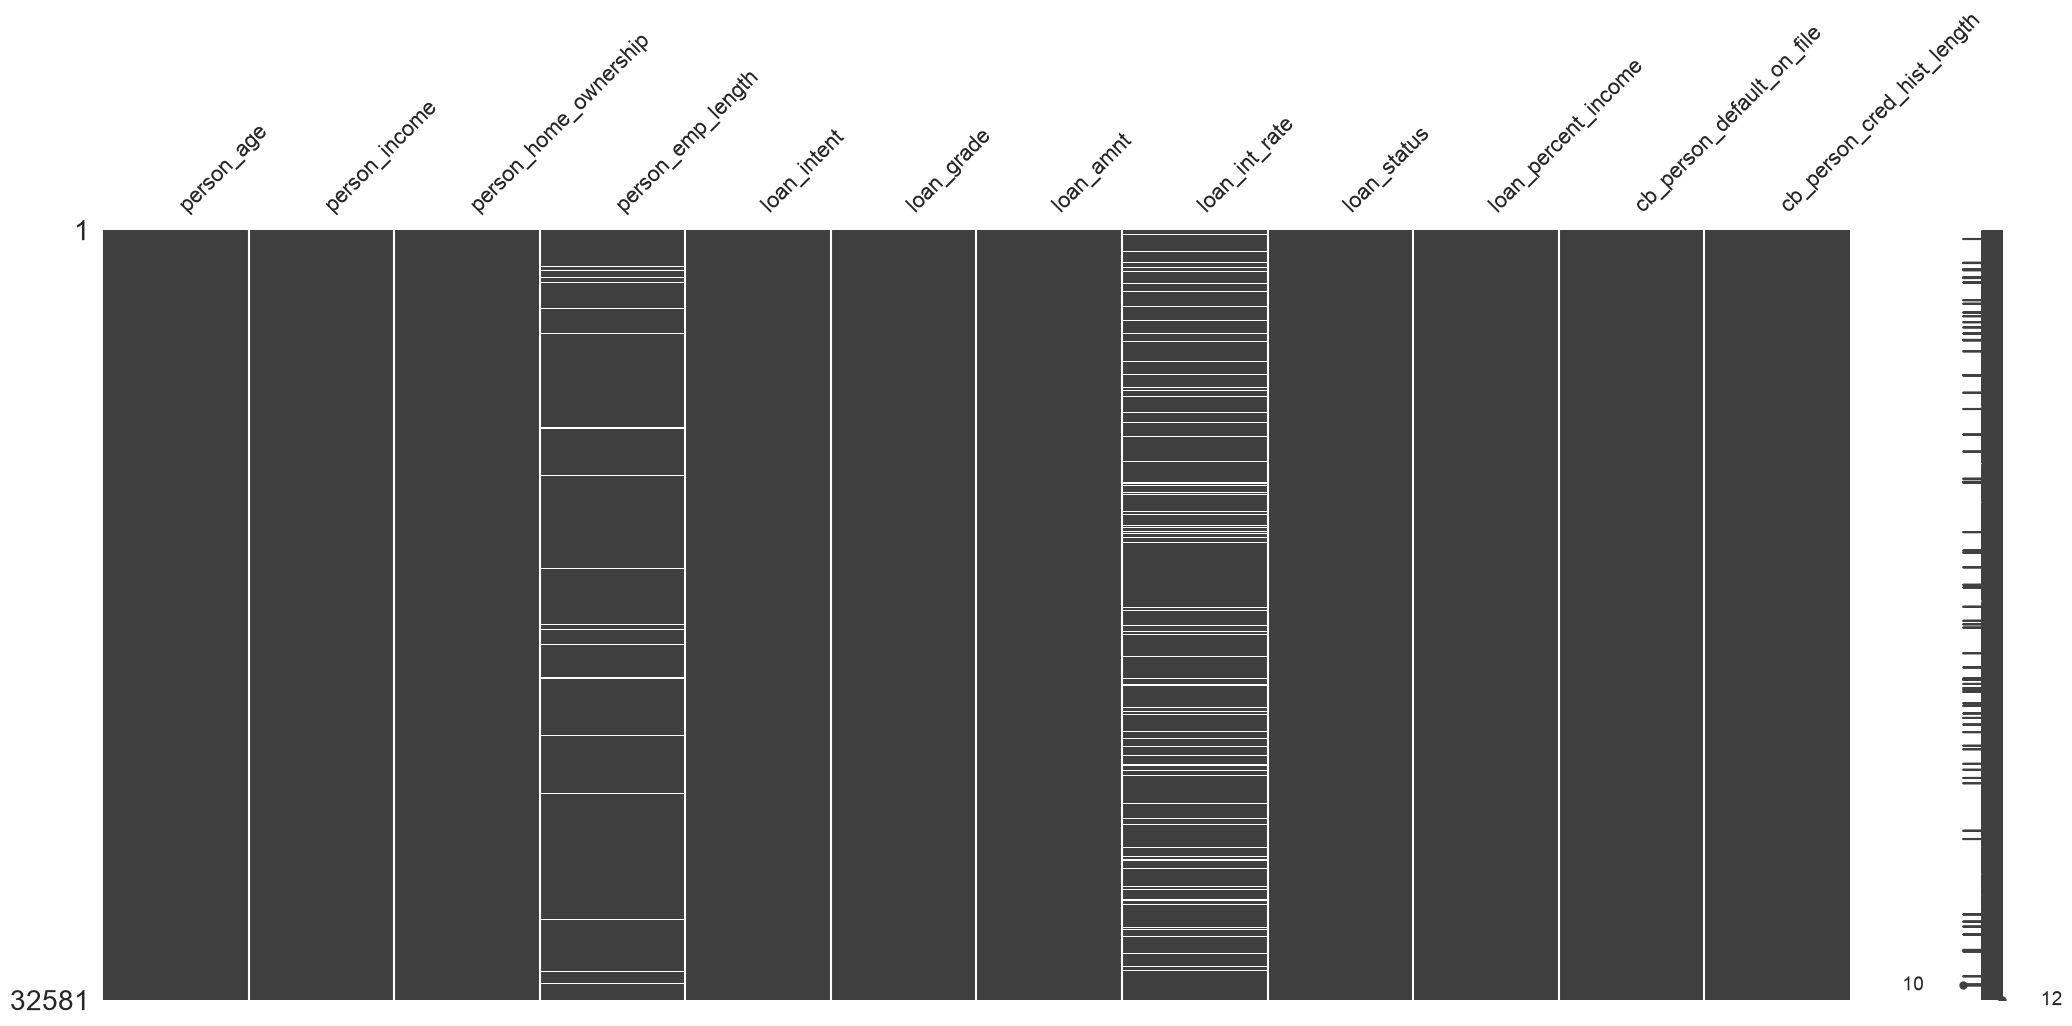

In [22]:
msno.matrix(df)
plt.show()

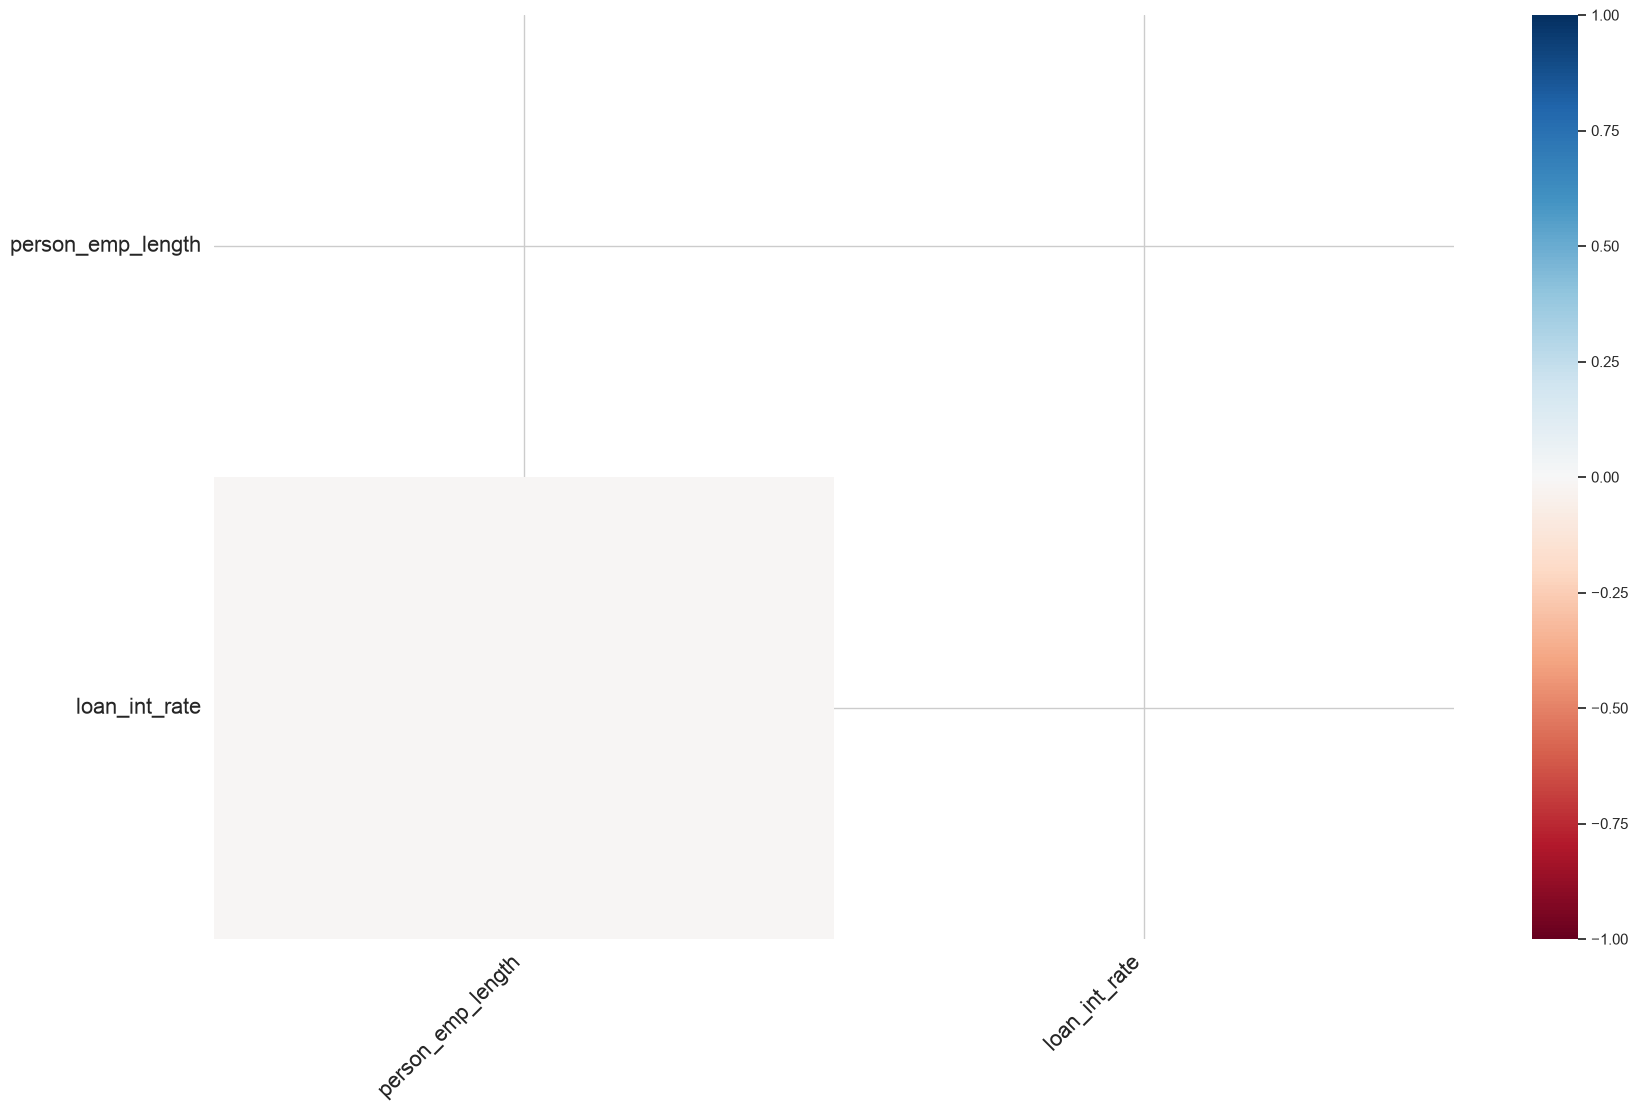

In [23]:
msno.heatmap(df)
plt.show()

In [24]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 165


In [25]:
df.dtypes

person_age                      int64
person_income                   int64
person_home_ownership             str
person_emp_length             float64
loan_intent                       str
loan_grade                        str
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file         str
cb_person_cred_hist_length      int64
dtype: object

In [26]:
for col in df.select_dtypes(include="object").columns:
    print(f"\n{col}")
    print(df[col].value_counts())


person_home_ownership
person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64

loan_intent
loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

loan_grade
loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64

cb_person_default_on_file
cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64


/var/folders/h7/xtvfsy8s20z6mwwy81g2ln700000gn/T/ipykernel_60688/1325783283.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


### Data Quality Summary

- Missing values exist in `person_emp_length` and `loan_int_rate`.
- 165 duplicate rows were found.
- Data types are appropriate for analysis.
- Categorical columns contain consistent category names.

In [27]:
df_clean = df.copy()

In [28]:
df_clean.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [29]:
df_clean["person_emp_length"] = df_clean["person_emp_length"].fillna(
    df_clean["person_emp_length"].median()
)

In [30]:
df_clean["loan_int_rate"] = df_clean["loan_int_rate"].fillna(
    df_clean["loan_int_rate"].median()
)

In [31]:
df_clean.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [32]:
duplicates = df_clean.duplicated().sum()
print(f"Duplicate Rows Before: {duplicates}")

Duplicate Rows Before: 165


In [33]:
df_clean = df_clean.drop_duplicates()

In [34]:
print(df_clean.duplicated().sum())

0


In [35]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 32416 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32416 non-null  int64  
 1   person_income               32416 non-null  int64  
 2   person_home_ownership       32416 non-null  str    
 3   person_emp_length           32416 non-null  float64
 4   loan_intent                 32416 non-null  str    
 5   loan_grade                  32416 non-null  str    
 6   loan_amnt                   32416 non-null  int64  
 7   loan_int_rate               32416 non-null  float64
 8   loan_status                 32416 non-null  int64  
 9   loan_percent_income         32416 non-null  float64
 10  cb_person_default_on_file   32416 non-null  str    
 11  cb_person_cred_hist_length  32416 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.2 MB


In [36]:
df_clean["person_age"].describe()

count    32416.000000
mean        27.747008
std          6.354100
min         20.000000
25%         23.000000
50%         26.000000
75%         30.000000
max        144.000000
Name: person_age, dtype: float64

In [37]:
df_clean[df_clean["person_age"] > 100]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
81,144,250000,RENT,4.0,VENTURE,C,4800,13.57,0,0.02,N,3
183,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.86,0,0.03,N,2
575,123,80004,RENT,2.0,EDUCATION,B,20400,10.25,0,0.25,N,3
747,123,78000,RENT,7.0,VENTURE,B,20000,10.99,0,0.26,N,4
32297,144,6000000,MORTGAGE,12.0,PERSONAL,C,5000,12.73,0,0.00,N,25


In [38]:
df_clean["person_emp_length"].describe()

count    32416.000000
mean         4.768880
std          4.090411
min          0.000000
25%          2.000000
50%          4.000000
75%          7.000000
max        123.000000
Name: person_emp_length, dtype: float64

In [39]:
df_clean[df_clean["person_emp_length"] > 60]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
210,21,192000,MORTGAGE,123.0,VENTURE,A,20000,6.54,0,0.10,N,4


In [40]:
df_clean = df_clean[df_clean["person_age"] <= 100]

In [41]:
print("Original Shape :", df.shape)
print("Cleaned Shape  :", df_clean.shape)

Original Shape : (32581, 12)
Cleaned Shape  : (32411, 12)


In [42]:
df_clean.to_csv(
    "../data/processed/credit_risk_cleaned.csv",
    index=False
)

In [43]:
import os

os.path.exists("../data/processed/credit_risk_cleaned.csv")

True

### Data Cleaning Summary

The dataset was cleaned by:

- Filling missing values in `person_emp_length` using the median.
- Filling missing values in `loan_int_rate` using the median.
- Removing duplicate records (if any).
- Removing unrealistic age values (>100 years).
- Removing unrealistic employment lengths (>60 years).
- Saving the cleaned dataset for further exploratory analysis.
